In [3]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load data
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

# Binary outcome: exact correct estimate or not
df["correct_estimate"] = (
    df["ai_estimated_mistakes"] == df["true_mistakes"]
).astype(int)


def chi_square_accuracy_by_true_mistakes(data):
    data = data.copy()

    # Contingency table: true mistakes x correct/incorrect
    table = pd.crosstab(
        data["true_mistakes"],
        data["correct_estimate"]
    )

    # Make sure both columns exist
    table = table.reindex(columns=[0, 1], fill_value=0)

    # Rename columns
    table = table.rename(columns={0: "incorrect", 1: "correct"})

    # Chi-square test of independence
    chi2, p, dof, expected = chi2_contingency(table)

    expected_table = pd.DataFrame(
        expected,
        index=table.index,
        columns=table.columns
    )

    accuracy_table = (
        table.assign(
            total=table["incorrect"] + table["correct"],
            accuracy_percent=table["correct"] / (table["incorrect"] + table["correct"]) * 100
        )
    )

    return chi2, p, dof, table, expected_table, accuracy_table

In [6]:
chi2, p, dof, table, expected_table, accuracy_table = chi_square_accuracy_by_true_mistakes(df)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

display(table)
display(accuracy_table)

Chi-square: 92.54458102552825
p-value: 3.3167127879806574e-13
Degrees of freedom: 15


correct_estimate,incorrect,correct
true_mistakes,,
0,47,453
1,74,426
2,88,412
3,90,410
4,75,424
5,83,417
6,93,407
7,81,419
8,113,386


correct_estimate,incorrect,correct,total,accuracy_percent
true_mistakes,,,,
0,47,453,500,90.600000
1,74,426,500,85.200000
2,88,412,500,82.400000
3,90,410,500,82.000000
4,75,424,499,84.969940
5,83,417,500,83.400000
6,93,407,500,81.400000
7,81,419,500,83.800000
8,113,386,499,77.354709


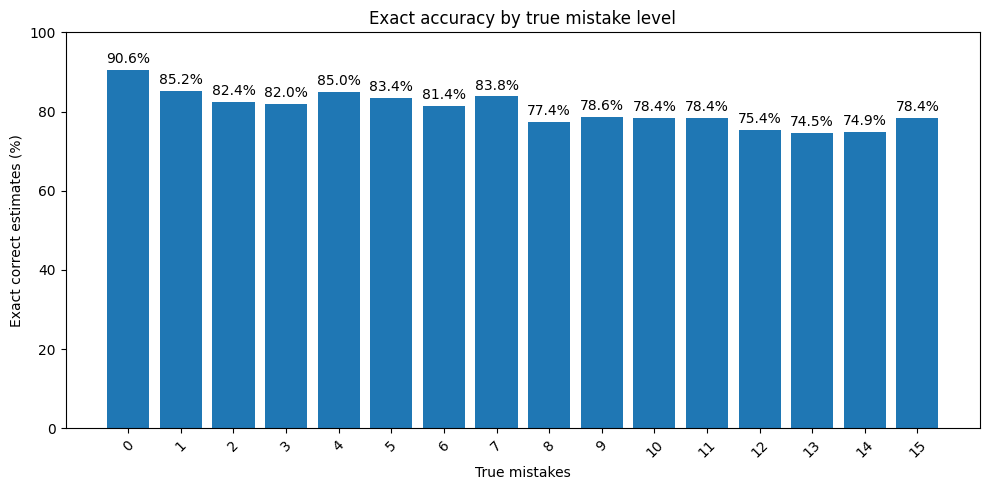

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("Output_extraction/ai_grading_final_v3.csv")

# Binary outcome: exact correct estimate or not
df["correct_estimate"] = (
    df["ai_estimated_mistakes"] == df["true_mistakes"]
).astype(int)

# Accuracy by true mistake group
accuracy_by_true_mistake = (
    df.groupby("true_mistakes")["correct_estimate"]
    .mean()
    .mul(100)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))
bars = plt.bar(
    accuracy_by_true_mistake["true_mistakes"].astype(str),
    accuracy_by_true_mistake["correct_estimate"]
)

# Labels above bars
for bar, value in zip(bars, accuracy_by_true_mistake["correct_estimate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Exact accuracy by true mistake level")
plt.xlabel("True mistakes")
plt.ylabel("Exact correct estimates (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()